#  Semantic Search pada Dataset Arsip
**Model:** DistilBERT | **Vector DB:** FAISS | **Evaluasi:** Precision@K

Notebook ini membangun sistem semantic search lengkap dengan alur:
1. Load & Preprocessing Dataset
2. Embedding dengan DistilBERT
3. Indexing dengan FAISS
4. Query & Similarity Search
5. Evaluasi Precision@K

##  Instalasi Library

In [1]:
# Install library yang dibutuhkan (khusus Kaggle environment)
!pip install -q faiss-cpu transformers openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 81.3 MB/s eta 0:00:00:00:0100:01


## 1️. Import Library

In [2]:
import re
import numpy as np
import pandas as pd
import faiss
import time
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from transformers import AutoTokenizer, AutoModel
from IPython.display import display


# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print('✅ Semua library berhasil diimport')
print(f'   PyTorch version : {torch.__version__}')
print(f'   FAISS version   : {faiss.__version__}')
print(f'   Device          : {"GPU" if torch.cuda.is_available() else "CPU"}')

✅ Semua library berhasil diimport
   PyTorch version : 2.10.0+cu128
   FAISS version   : 1.14.3
   Device          : GPU


## 2️. identifikasi dataset

In [3]:
# ── Sesuaikan path dengan lokasi file di Kaggle ──
# Jika upload via Kaggle Datasets, path-nya:
# '/kaggle/input/<nama-dataset>/dataset_arsip.xlsx'
FILE_PATH = '/kaggle/input/datasets/muhammadhaekal74/dataset-arsip/dataset_arsip.xlsx'

# Load dataset
df = pd.read_excel(FILE_PATH)

print(f'✅ Dataset berhasil dimuat')
print(f'   Jumlah baris   : {len(df):,}')
print(f'   Jumlah kolom   : {len(df.columns)}')
print(f'   Kolom tersedia : {df.columns.tolist()}')
print()
display(df[['title', 'description', 'keywords', 'categoryId']].head(3))

✅ Dataset berhasil dimuat
   Jumlah baris   : 784
   Jumlah kolom   : 18
   Kolom tersedia : ['id', 'uuid', 'title', 'document_number', 'year', 'description', 'file_path', 'file_name', 'mime_type', 'file_size_kb', 'created_at', 'updated_at', 'uploaderId', 'categoryId', 'access_level', 'unitKerjaId', 'keywords', 'suratId']



,title,description,keywords,categoryId
0,Pengangkatan tim Perumus Visi dan Misi Univers...,Dokumen ini berisi tentang amanat Rektor perih...,"SK, Rektor, pengangkatan, tim perumus, visi da...",3
1,Visi dan Misi Universitas Darussalam Gontor,Dokumen ini berisi tentang Visi dan Misi Unive...,"SK, Keputusan, Rektor, Visi dan Misi, UNIDA",3
2,Penetapan Struktur Fungsionaris Centre For Isl...,Dokumen ini berisi tentang nama - nama yang di...,"SK, Rektor, Fungsionaris, CIES, UNIDA",3


## 3️. Pra pemrosesan data

In [4]:
def clean_text(text: str) -> str:
    """Bersihkan teks: lowercase, hapus karakter khusus, normalisasi spasi."""
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = text.lower()                          # Lowercase
    text = re.sub(r'[^a-z0-9\s]', ' ', text)    # Hapus karakter khusus
    text = re.sub(r'\s+', ' ', text).strip()     # Normalisasi spasi
    return text


def build_combined_text(row: pd.Series) -> str:
    """Gabungkan kolom title + description + keywords menjadi satu teks."""
    parts = [
        clean_text(str(row.get('title', ''))),
        clean_text(str(row.get('description', ''))),
        clean_text(str(row.get('keywords', '')))
    ]
    return ' '.join(p for p in parts if p)  # Abaikan bagian yang kosong


# Terapkan preprocessing
df['combined_text'] = df.apply(build_combined_text, axis=1)

# Hapus baris dengan teks kosong setelah preprocessing
df = df[df['combined_text'].str.strip() != ''].reset_index(drop=True)

print('✅ Preprocessing selesai')
print(f'   Dokumen valid  : {len(df):,}')
print()
print('Contoh combined_text (baris pertama):')
print(df['combined_text'].iloc[0])

✅ Preprocessing selesai
   Dokumen valid  : 784

Contoh combined_text (baris pertama):
pengangkatan tim perumus visi dan misi universitas darussalam gontor dokumen ini berisi tentang amanat rektor perihal pengangkatan nama nama terlampir sebagai tim perumus visi dan misi universitas darussalam gontor sk rektor pengangkatan tim perumus visi dan misi


## 4️. pembentukan Embedding dengan DistilBERT

In [5]:
# ── Konfigurasi Model ──────────────────────────────────────────
MODEL_NAME  = 'distilbert-base-uncased'   # Model DistilBERT 
BATCH_SIZE  = 32                           # Sesuaikan dengan RAM/VRAM
MAX_LENGTH  = 256                          # Panjang maksimum token input
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load tokenizer dan model
print(f'🔄 Memuat model "{MODEL_NAME}" ke {DEVICE.upper()}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()
print('✅ Model berhasil dimuat')

🔄 Memuat model "distilbert-base-uncased" ke CUDA...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model berhasil dimuat


In [6]:
def mean_pooling(model_output, attention_mask):
    """
    Mean Pooling: rata-rata token embedding yang valid (bukan padding).
    Menghasilkan satu vektor representasi per kalimat.
    """
    token_embeddings = model_output.last_hidden_state          # (B, L, H)
    mask_expanded    = attention_mask.unsqueeze(-1).float()    # (B, L, 1)
    sum_embeddings   = (token_embeddings * mask_expanded).sum(1)  # (B, H)
    sum_mask         = mask_expanded.sum(1).clamp(min=1e-9)       # (B, 1)
    return sum_embeddings / sum_mask                              # (B, H)


def encode_texts(texts: list, batch_size: int = BATCH_SIZE) -> np.ndarray:
    """
    Ubah daftar teks menjadi matriks embedding (N × D).
    Diproses secara batch untuk efisiensi memori.
    """
    all_embeddings = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start : start + batch_size]

        # Tokenisasi batch
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors='pt'
        ).to(DEVICE)

        # Inferensi tanpa gradient (hemat memori)
        with torch.no_grad():
            output = model(**encoded)

        # Mean pooling → pindahkan ke CPU → konversi ke numpy
        embeddings = mean_pooling(output, encoded['attention_mask'])
        all_embeddings.append(embeddings.cpu().numpy())

        # Progress setiap 100 batch
        batch_num = start // batch_size + 1
        total_batches = (len(texts) + batch_size - 1) // batch_size
        if batch_num % 5 == 0 or batch_num == total_batches:
            print(f'   Batch {batch_num:>3}/{total_batches} selesai '
                  f'({min(start+batch_size, len(texts))}/{len(texts)} teks)')

    return np.vstack(all_embeddings).astype(np.float32)


# Encode semua dokumen
print('🔄 Membuat embedding untuk seluruh dokumen...')
doc_embeddings = encode_texts(df['combined_text'].tolist())

print()
print('✅ Embedding selesai')
print(f'   Shape embedding : {doc_embeddings.shape}  (dokumen × dimensi)')

🔄 Membuat embedding untuk seluruh dokumen...
   Batch   5/25 selesai (160/784 teks)
   Batch  10/25 selesai (320/784 teks)
   Batch  15/25 selesai (480/784 teks)
   Batch  20/25 selesai (640/784 teks)
   Batch  25/25 selesai (784/784 teks)

✅ Embedding selesai
   Shape embedding : (784, 768)  (dokumen × dimensi)


## 5️. Normalisasi & Indexing FAISS (Cosine Similarity)

In [7]:
# Normalisasi L2 → Inner Product menjadi setara dengan Cosine Similarity
faiss.normalize_L2(doc_embeddings)

# Buat FAISS index dengan Inner Product (cosine setelah normalisasi)
EMBEDDING_DIM = doc_embeddings.shape[1]
index = faiss.IndexFlatIP(EMBEDDING_DIM)   # IP = Inner Product

# Tambahkan semua embedding ke index
index.add(doc_embeddings)

print('✅ FAISS index berhasil dibuat')
print(f'   Tipe index        : IndexFlatIP (Cosine Similarity)')
print(f'   Dimensi embedding : {EMBEDDING_DIM}')
print(f'   Total vektor      : {index.ntotal:,}')

✅ FAISS index berhasil dibuat
   Tipe index        : IndexFlatIP (Cosine Similarity)
   Dimensi embedding : 768
   Total vektor      : 784


## 6️. Penyusunan Query uji

In [8]:
SAMPLE_QUERIES = [
    'pengangkatan rektor universitas',
    'visi misi lembaga pendidikan',
    'struktur organisasi fungsionaris',
    'keputusan mahkamah agung hukum',
    'anggaran keuangan belanja tahunan',
    'surat keputusan kepegawaian pegawai',
    'kerjasama perjanjian institusi pendidikan'
]

TOP_K = 5   # Jumlah dokumen teratas yang diambil


def search(query: str, k: int = TOP_K) -> tuple:
    """
    Cari dokumen paling relevan untuk satu query.

    Returns:
        indices: indeks baris di DataFrame
        scores : cosine similarity score (0–1)
    """
    # Preprocessing query (sama dengan dokumen)
    clean_query  = clean_text(query)

    # Encode query menjadi embedding
    query_vector = encode_texts([clean_query])   # shape: (1, D)
    faiss.normalize_L2(query_vector)              # Normalisasi L2

    # Cari Top-K dokumen terdekat di FAISS index
    scores, indices = index.search(query_vector, k)

    return indices[0], scores[0]   # Ambil hasil untuk query pertama (satu query)


print(f'✅ Fungsi search siap. TOP_K = {TOP_K}')

✅ Fungsi search siap. TOP_K = 5


## 7️. Evaluasi sistem (Precision@K)

In [9]:
def precision_at_k(relevant_category: int, result_indices: np.ndarray, k: int) -> float:
    """
    Hitung Precision@K menggunakan pseudo ground truth berbasis categoryId.

    Asumsi relevansi: dokumen hasil dianggap relevan jika categoryId-nya
    sama dengan categoryId dokumen pertama pada hasil pencarian.

    Formula:
        Precision@K = (# dokumen relevan dalam Top-K) / K
    """
    top_k_indices = result_indices[:k]
    top_k_categories = df.loc[top_k_indices, 'categoryId'].values

    # Hitung berapa dokumen yang categoryId-nya sama dengan kategori relevan
    num_relevant = np.sum(top_k_categories == relevant_category)

    return num_relevant / k


print('✅ Fungsi precision_at_k siap')

✅ Fungsi precision_at_k siap


## 7.1 Average Precision (AP) & Mean Average Precision (MAP)

In [10]:
def average_precision(relevant_category: int, result_indices: np.ndarray) -> float:
    """
    Hitung Average Precision (AP) untuk satu query.

    AP menghitung precision hanya di posisi dokumen relevan,
    lalu dirata-rata. Berbeda dengan Precision@K, AP
    memperhitungkan URUTAN ranking dokumen relevan muncul.

    Formula:
        AP = (1/R) * Σ Precision@k  untuk setiap k dimana dokumen relevan
        R  = jumlah dokumen relevan yang ditemukan
    """
    categories = df.loc[result_indices, 'categoryId'].values

    relevant_hits = 0
    precision_sum = 0.0

    for k, cat in enumerate(categories, start=1):
        if cat == relevant_category:
            relevant_hits += 1
            precision_at_this_k = relevant_hits / k
            precision_sum += precision_at_this_k

    if relevant_hits == 0:
        return 0.0

    return precision_sum / relevant_hits


print('✅ Fungsi average_precision siap')

✅ Fungsi average_precision siap


## 8️. Perankingan ahsil pencarian

In [11]:
# Mapping categoryId ke nama kategori 
CATEGORY_NAMES = {
    1: 'Kategori-1',
    2: 'Kategori-2',
    3: 'Kategori-3',
    4: 'Kategori-4',
    5: 'Kategori-5',
    6: 'Kategori-6',
    7: 'Kategori-7',
    8: 'Kategori-8',
}


def run_and_display(query: str, k: int = TOP_K):
    """Jalankan search untuk satu query dan tampilkan hasil lengkap."""

    # ── Pencarian ─────────────────────────────────────────────────────────────
    indices, scores = search(query, k)

    # ── Pseudo Ground Truth: kategori dokumen dengan skor tertinggi ───────────
    top1_category = df.loc[indices[0], 'categoryId']

    # ── Precision@K ───────────────────────────────────────────────────────────
    prec_at_k = precision_at_k(top1_category, indices, k)
    ap_score = average_precision(top1_category, indices)
    
    # ── Tampilkan Header ──────────────────────────────────────────────────────
    sep = '═' * 78
    print(sep)
    print(f'   QUERY   : "{query}"')
    print(f'  📊 Precision@{k} : {prec_at_k:.2%}   |   AP : {ap_score:.2%}   '
          f'(ground truth category = {top1_category})')
    print(sep)

    # ── Tampilkan Top-K Hasil ─────────────────────────────────────────────────
    rows = []
    for rank, (idx, score) in enumerate(zip(indices, scores), start=1):
        row = df.loc[idx]
        cat_id = row['categoryId']
        cat_name = CATEGORY_NAMES.get(cat_id, f'Cat-{cat_id}')
        relevant = '✅' if cat_id == top1_category else '❌'

        rows.append({
            'Rank'      : rank,
            'Score'     : f'{score:.4f}',
            'Relevan'   : relevant,
            'CategoryId': cat_id,
            'Category'  : cat_name,
            'Title'     : str(row['title'])[:65] + ('…' if len(str(row['title'])) > 65 else ''),
        })

    result_df = pd.DataFrame(rows).set_index('Rank')
    display(result_df)
    print()

    return prec_at_k, ap_score


# ── Jalankan semua query ───────────────────────────────────────────────────────
print(' Menjalankan semantic search untuk semua query...\n')
all_precision = []
all_ap = []

for q in SAMPLE_QUERIES:
    p, ap = run_and_display(q, k=TOP_K)
    all_precision.append(p)
    all_ap.append(ap)

 Menjalankan semantic search untuk semua query...

   Batch   1/1 selesai (1/1 teks)
══════════════════════════════════════════════════════════════════════════════
   QUERY   : "pengangkatan rektor universitas"
  📊 Precision@5 : 80.00%   |   AP : 95.00%   (ground truth category = 3)
══════════════════════════════════════════════════════════════════════════════


,Score,Relevan,CategoryId,Category,Title
Rank,,,,,
1,0.8970,✅,3,Kategori-3,Pembentukan Student And Alumni Development Cen...
2,0.8934,✅,3,Kategori-3,Peraturan Akademik
3,0.8859,✅,3,Kategori-3,Penempatan Staff Universitas Darussalam Gontor
4,0.8840,❌,6,Kategori-6,Panduan Akademik Universitas
5,0.8837,✅,3,Kategori-3,Pendirian Unit Kegiatan Mahasiswa



   Batch   1/1 selesai (1/1 teks)
══════════════════════════════════════════════════════════════════════════════
   QUERY   : "visi misi lembaga pendidikan"
  📊 Precision@5 : 60.00%   |   AP : 100.00%   (ground truth category = 8)
══════════════════════════════════════════════════════════════════════════════


,Score,Relevan,CategoryId,Category,Title
Rank,,,,,
1,0.8954,✅,8,Kategori-8,SOP Penyerahan NIlai
2,0.8952,✅,8,Kategori-8,SOP Surat Masuk
3,0.8915,✅,8,Kategori-8,SOP Perizinan Dosen
4,0.8901,❌,3,Kategori-3,Pendirian Unit Kegiatan Mahasiswa
5,0.8900,❌,3,Kategori-3,Pendirian Unit Kegiatan Mahasiswa



   Batch   1/1 selesai (1/1 teks)
══════════════════════════════════════════════════════════════════════════════
   QUERY   : "struktur organisasi fungsionaris"
  📊 Precision@5 : 40.00%   |   AP : 70.00%   (ground truth category = 3)
══════════════════════════════════════════════════════════════════════════════


...

,Score,Relevan,CategoryId,Category,Title
Rank,,,,,
1,0.9107,✅,8,Kategori-8,SOP Pengajuan Anggaran
2,0.8929,❌,3,Kategori-3,Pendirian Unit Kegiatan Mahasiswa
3,0.8900,❌,3,Kategori-3,Pembentukan Student And Alumni Development Cen...
4,0.8896,❌,3,Kategori-3,Data Fasilitas Asrama
5,0.8872,❌,3,Kategori-3,Pemberlakuan Program Bahasa



   Batch   1/1 selesai (1/1 teks)
══════════════════════════════════════════════════════════════════════════════
   QUERY   : "surat keputusan kepegawaian pegawai"
  📊 Precision@5 : 100.00%   |   AP : 100.00%   (ground truth category = 3)
══════════════════════════════════════════════════════════════════════════════


,Score,Relevan,CategoryId,Category,Title
Rank,,,,,
1,0.9120,✅,3,Kategori-3,Pendirian Unit Kegiatan Mahasiswa
2,0.9083,✅,3,Kategori-3,Pembentukan Student And Alumni Development Cen...
3,0.9063,✅,3,Kategori-3,Pendirian Unit Kegiatan Mahasiswa
4,0.9062,✅,3,Kategori-3,Pendirian Unit Kegiatan Mahasiswa
5,0.9051,✅,3,Kategori-3,Data Fasilitas Asrama



   Batch   1/1 selesai (1/1 teks)
══════════════════════════════════════════════════════════════════════════════
   QUERY   : "kerjasama perjanjian institusi pendidikan"
  📊 Precision@5 : 40.00%   |   AP : 75.00%   (ground truth category = 8)
══════════════════════════════════════════════════════════════════════════════


,Score,Relevan,CategoryId,Category,Title
Rank,,,,,
1,0.9235,✅,8,Kategori-8,SOP Perjanjian Kerja
2,0.9149,❌,3,Kategori-3,Pendirian Unit Kegiatan Mahasiswa
3,0.9102,❌,3,Kategori-3,Pendirian Unit Kegiatan Mahasiswa
4,0.9084,✅,8,Kategori-8,SOP Penyerahan NIlai
5,0.9074,❌,3,Kategori-3,Pendirian Unit Kegiatan Mahasiswa


## 9️. Ringkasan Evaluasi

In [12]:
# ── Tampilkan mean Precision@K untuk semua query ──────────────────────────────
summary = pd.DataFrame({
    'Query'              : SAMPLE_QUERIES,
    f'Precision@{TOP_K}' : [f'{p:.2%}' for p in all_precision],
    'AP'                 : [f'{a:.2%}' for a in all_ap]
})

mean_precision = np.mean(all_precision)
map_score = np.mean(all_ap)

mean_precision = np.mean(all_precision)

print('=' * 55)
print(f'   RINGKASAN EVALUASI — Mean Precision@{TOP_K}')
print('=' * 55)
display(summary)
print()
print(f'  ✅ Mean Precision@{TOP_K} : {mean_precision:.2%}')
print(f'  ✅ MAP (Mean Average Precision) : {map_score:.2%}')
print('=' * 55)

   RINGKASAN EVALUASI — Mean Precision@5


,Query,Precision@5,AP
0,pengangkatan rektor universitas,80.00%,95.00%
1,visi misi lembaga pendidikan,60.00%,100.00%
2,struktur organisasi fungsionaris,40.00%,70.00%
3,keputusan mahkamah agung hukum,80.00%,88.75%
4,anggaran keuangan belanja tahunan,20.00%,100.00%
5,surat keputusan kepegawaian pegawai,100.00%,100.00%
6,kerjasama perjanjian institusi pendidikan,40.00%,75.00%



  ✅ Mean Precision@5 : 60.00%
  ✅ MAP (Mean Average Precision) : 89.82%


## 9.1 Pengukuran Query Latency

In [13]:
# ── Pengukuran Query Latency 
# Query latency = waktu total yang dibutuhkan sistem untuk memproses satu query
# Mencakup: preprocessing → encoding → normalisasi → FAISS search

latencies_ms = []

for q in SAMPLE_QUERIES:
    start = time.time()                          # Mulai stopwatch

    clean_q      = clean_text(q)                 # Preprocessing
    query_vector = encode_texts([clean_q])        # Encoding (DistilBERT)
    faiss.normalize_L2(query_vector)              # Normalisasi L2
    _, _ = index.search(query_vector, TOP_K)      # FAISS search

    latency_ms = (time.time() - start) * 1000    # Konversi ke milidetik
    latencies_ms.append(latency_ms)

# ── Hasil Pengukuran 
avg_latency  = np.mean(latencies_ms)
min_latency  = np.min(latencies_ms)
max_latency  = np.max(latencies_ms)
throughput   = 1000 / avg_latency               # queries per detik

# ── Tabel Latency per Query 
latency_df = pd.DataFrame({
    'Query'         : SAMPLE_QUERIES,
    'Latency (ms)'  : [f'{l:.2f}' for l in latencies_ms]
})
display(latency_df)

# ── Ringkasan
print('=' * 55)
print('   RINGKASAN QUERY LATENCY')
print('=' * 55)
print(f'     Avg Latency  : {avg_latency:.2f} ms')
print(f'     Min Latency  : {min_latency:.2f} ms')
print(f'     Max Latency  : {max_latency:.2f} ms')
print(f'     Throughput   : {throughput:.2f} queries/detik')
print('=' * 55)

   Batch   1/1 selesai (1/1 teks)
   Batch   1/1 selesai (1/1 teks)
   Batch   1/1 selesai (1/1 teks)
   Batch   1/1 selesai (1/1 teks)
   Batch   1/1 selesai (1/1 teks)
   Batch   1/1 selesai (1/1 teks)
   Batch   1/1 selesai (1/1 teks)


,Query,Latency (ms)
0,pengangkatan rektor universitas,7.03
1,visi misi lembaga pendidikan,6.12
2,struktur organisasi fungsionaris,4.49
3,keputusan mahkamah agung hukum,4.53
4,anggaran keuangan belanja tahunan,4.28
5,surat keputusan kepegawaian pegawai,4.66
6,kerjasama perjanjian institusi pendidikan,4.36


   RINGKASAN QUERY LATENCY
     Avg Latency  : 5.07 ms
     Min Latency  : 4.28 ms
     Max Latency  : 7.03 ms
     Throughput   : 197.37 queries/detik


## 9.2 Visualisasi Evaluasi

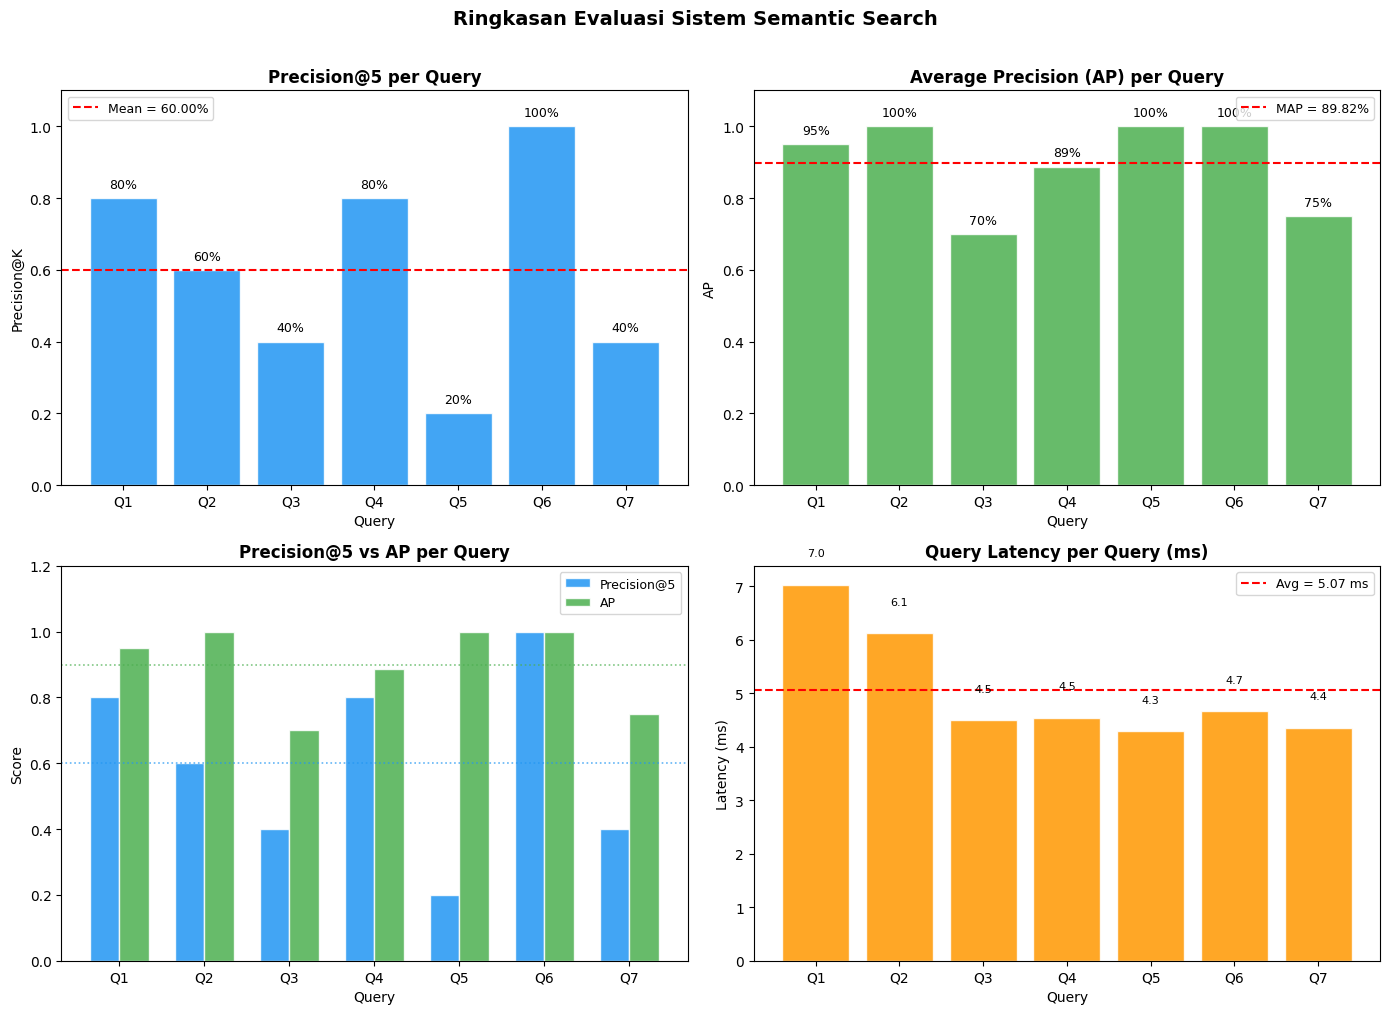

   RINGKASAN METRIK EVALUASI
  📊 Mean Precision@5 : 60.00%
  📊 MAP               : 89.82%
  ⏱  Avg Latency       : 5.07 ms
  ⚡ Throughput        : 197.37 queries/detik
✅ Visualisasi tersimpan: evaluasi_semantic_search.png


In [14]:
# ── Data dari hasil evaluasi sebelumnya ──────────────────────────────────────
queries_short = [f'Q{i+1}' for i in range(len(SAMPLE_QUERIES))]  # Q1, Q2, ..., Q7
precision_vals = all_precision
ap_vals        = all_ap
latency_vals   = latencies_ms

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Ringkasan Evaluasi Sistem Semantic Search', fontsize=14, fontweight='bold', y=1.01)

# ── Warna ─────────────────────────────────────────────────────────────────────
COLOR_PRECISION = '#2196F3'
COLOR_AP        = '#4CAF50'
COLOR_LATENCY   = '#FF9800'
COLOR_MAP       = '#9C27B0'

# ── Plot 1: Precision@K per Query ────────────────────────────────────────────
ax1 = axes[0, 0]
bars1 = ax1.bar(queries_short, precision_vals, color=COLOR_PRECISION, alpha=0.85, edgecolor='white')
ax1.axhline(y=np.mean(precision_vals), color='red', linestyle='--', linewidth=1.5, label=f'Mean = {np.mean(precision_vals):.2%}')
ax1.set_title(f'Precision@{TOP_K} per Query', fontweight='bold')
ax1.set_xlabel('Query')
ax1.set_ylabel('Precision@K')
ax1.set_ylim(0, 1.1)
ax1.legend(fontsize=9)
for bar, val in zip(bars1, precision_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.0%}', ha='center', va='bottom', fontsize=9)

# ── Plot 2: Average Precision (AP) per Query ─────────────────────────────────
ax2 = axes[0, 1]
bars2 = ax2.bar(queries_short, ap_vals, color=COLOR_AP, alpha=0.85, edgecolor='white')
ax2.axhline(y=np.mean(ap_vals), color='red', linestyle='--', linewidth=1.5, label=f'MAP = {np.mean(ap_vals):.2%}')
ax2.set_title('Average Precision (AP) per Query', fontweight='bold')
ax2.set_xlabel('Query')
ax2.set_ylabel('AP')
ax2.set_ylim(0, 1.1)
ax2.legend(fontsize=9)
for bar, val in zip(bars2, ap_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.0%}', ha='center', va='bottom', fontsize=9)

# ── Plot 3: Precision@K vs AP (perbandingan per query) ───────────────────────
ax3 = axes[1, 0]
x    = np.arange(len(queries_short))
w    = 0.35
bar3a = ax3.bar(x - w/2, precision_vals, w, label=f'Precision@{TOP_K}', color=COLOR_PRECISION, alpha=0.85, edgecolor='white')
bar3b = ax3.bar(x + w/2, ap_vals,        w, label='AP',                  color=COLOR_AP,        alpha=0.85, edgecolor='white')
ax3.set_title(f'Precision@{TOP_K} vs AP per Query', fontweight='bold')
ax3.set_xlabel('Query')
ax3.set_ylabel('Score')
ax3.set_ylim(0, 1.2)
ax3.set_xticks(x)
ax3.set_xticklabels(queries_short)
ax3.legend(fontsize=9)
ax3.axhline(y=np.mean(precision_vals), color=COLOR_PRECISION, linestyle=':', linewidth=1.2, alpha=0.7)
ax3.axhline(y=np.mean(ap_vals),        color=COLOR_AP,        linestyle=':', linewidth=1.2, alpha=0.7)

# ── Plot 4: Query Latency per Query ──────────────────────────────────────────
ax4 = axes[1, 1]
bars4 = ax4.bar(queries_short, latency_vals, color=COLOR_LATENCY, alpha=0.85, edgecolor='white')
ax4.axhline(y=np.mean(latency_vals), color='red', linestyle='--', linewidth=1.5,
            label=f'Avg = {np.mean(latency_vals):.2f} ms')
ax4.set_title('Query Latency per Query (ms)', fontweight='bold')
ax4.set_xlabel('Query')
ax4.set_ylabel('Latency (ms)')
ax4.legend(fontsize=9)
for bar, val in zip(bars4, latency_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('evaluasi_semantic_search.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Ringkasan akhir ───────────────────────────────────────────────────────────
print('=' * 55)
print('   RINGKASAN METRIK EVALUASI')
print('=' * 55)
print(f'  📊 Mean Precision@{TOP_K} : {np.mean(precision_vals):.2%}')
print(f'  📊 MAP               : {np.mean(ap_vals):.2%}')
print(f'  ⏱  Avg Latency       : {np.mean(latency_vals):.2f} ms')
print(f'  ⚡ Throughput        : {1000/np.mean(latency_vals):.2f} queries/detik')
print('=' * 55)
print('✅ Visualisasi tersimpan: evaluasi_semantic_search.png')

## 10. Interactive Search


In [15]:
# ── Ganti query di bawah sesuai kebutuhan ──
CUSTOM_QUERY = 'identitas mahasiswa'

p, ap = run_and_display(CUSTOM_QUERY, k=TOP_K)

   Batch   1/1 selesai (1/1 teks)
══════════════════════════════════════════════════════════════════════════════
   QUERY   : "identitas mahasiswa"
  📊 Precision@5 : 20.00%   |   AP : 100.00%   (ground truth category = 1)
══════════════════════════════════════════════════════════════════════════════


,Score,Relevan,CategoryId,Category,Title
Rank,,,,,
1,0.7256,✅,1,Kategori-1,Foto Rektor Unida bersama Hagia Sophia and Pro...
2,0.7206,❌,8,Kategori-8,SOP Registrasi Mahasiswa Baru
3,0.7201,❌,8,Kategori-8,SOP Surat Izin Penelitian Mahasiswa
4,0.7192,❌,3,Kategori-3,Data Fasilitas Asrama
5,0.7161,❌,3,Kategori-3,Pendirian Unit Kegiatan Mahasiswa
